In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from utils import DATA_DIR, ROOT_DIR
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts'))
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts/scaling'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataloader import get_nd_array, get_slice
from download.weka import pull_predictions_from_weka
from download.hf import pull_predictions_from_hf

import ladder
plt.close()

In [3]:
# bucket_name = 'oe-eval-default'
# file_key = f'davidh/metaeval/analysis/data/aws_metrics.csv'
# local_path = f'{DATA_DIR}/aws_metrics.csv'
# download_from_weka(bucket_name, file_key, local_path)

local_path = pull_predictions_from_hf("allenai/ladder-evals", "benchmarks")

In [4]:
# df = pd.read_csv(local_path)
df = pd.read_parquet(local_path)
print(f'Loaded {len(df):,} model evaluations')

# Preprocess the df into a usuable format
df = df.drop(columns=["Unnamed: 0"], errors='ignore')

# Modify column order to move these up
desired_order = ['model', 'mix', 'step', 'size', 'token_ratio', 'task', 'primary_score', 'logits_per_byte_corr']
existing_columns = [col for col in desired_order if col in df.columns]
remaining_cols = [col for col in df.columns if col not in existing_columns]
df = df[existing_columns + remaining_cols]

# Add primary score if it does not exist
if 'primary_score' in df.columns:
    if 'acc_per_char' in df.columns:
        df['primary_score'] = df['primary_score'].fillna(df['acc_per_char'])
    if 'exact_match' in df.columns:
        df['primary_score'] = df['primary_score'].fillna(df['exact_match'])
    if 'pass_at_1' in df.columns:
        df['primary_score'] = df['primary_score'].fillna(df['pass_at_1'])

Loaded 97,970 model evaluations


In [5]:
def task_tag(task_name):
    return task_name.split("::")[0].replace(":rc", "") if "::" in task_name else task_name

In [6]:
MODELS = list(df['model'].unique())
MIXES = list(df['mix'].unique())
STEPS = list(df['step'].unique())
TASKS = sorted(list(df['task'].unique()))

### Predicting RC with MC

In [7]:
from ladder import sort_experiment_names
from utils.constants_models import MODEL_LIST_MIXES

# Train models
all_ladder_models = [model for model in MODELS if 'peteish-moreeval' in model]
all_ladder_models = sort_experiment_names(all_ladder_models)

# Ladder config
ladder_config_path = f'{ROOT_DIR}/analysis/utils/ladder_config.json'

# Eval models
MODEL_LIST_MIXES = [model.split("/")[-1] for model in MODEL_LIST_MIXES]
BROKEN_MODELS = ["gemma-2b", "gemma-7b", "gemma-2-2b", "gemma-2-9b"] # gemma models broken in oe-eval
LLAMA_3_MODELS = [model for model in MODELS if 'Llama-3' in model]

all_models = sorted([model for model in MODELS if model not in MODEL_LIST_MIXES + BROKEN_MODELS + all_ladder_models])

In [ ]:
import matplotlib.pyplot as plt
from ladder import run_ladder

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

# task_name = "deepmind_math_large"
# task_name = ["arc_challenge", "arc_easy"]
# task_name = [t for t in TASKS if 'mmlu' in t and ':' not in t and '_pro_' not in t]
# task_name = [t for t in TASKS if 'minerva' in t and ':' not in t]
# task_name = [t for t in TASKS if '_pro_' in t and ':' not in t]
# task_name = [t for t in TASKS if 'agi_eval' in t and ':' not in t]
task_name = [t for t in TASKS if 'bbh' in t and ':' not in t]
# task_name = ['arc_challenge', 'arc_easy', 'boolq', 'csqa', 'hellaswag', 'openbookqa', 'piqa', 'socialiqa', 'winogrande']

_, _, _ = run_ladder(
    df,
    task_name,
    # train_models=all_ladder_models,
    train_models=[m for m in all_ladder_models if '1B' not in m],
    # train_models=[m for m in all_ladder_models if '3B' not in m and '1B' not in m],
    eval_models=["peteish7", "peteish13-highlr"],
    # eval_models=all_models,
    intermediate_feature="paloma_m2d2_s2orc_unsplit",
    config_path=ladder_config_path,
    axes=axes[0],
)

for ax in axes[0]:
    ax.set_title('aggregate')
    ax.legend(fontsize=4, ncols=2)

# Note: This looks off because it's primary_metric, not acc_per_char

In [9]:
pd.set_option('display.max_columns', None)

get_slice(df, task='codex_humaneval')

,index,model,mix,step,size,token_ratio,task,primary_score,logits_per_byte_corr,task_name,task_hash,model_hash,model_config,processing_time,current_date,num_instances,metrics,task_idx,acc_raw,acc_per_token,acc_per_char,logits_per_char_corr,acc_uncond,step_str,s3_path,exact_match_simple,exact_match,extra_metrics,pass_at_1,bits_per_byte,ppl_token,ppl_char,ppl_word,ppl_byte,exact_match_flex,f1,recall,exact_match_sub_mctest,exact_match_sub_race,exact_match_sub_cnn,exact_match_sub_wikipedia,exact_match_sub_gutenberg,f1_sub_mctest,f1_sub_race,f1_sub_cnn,f1_sub_wikipedia,f1_sub_gutenberg,pass_at_10,exact_match_sub_2022,exact_match_sub_2023,exact_match_sub_2024,exact_match_flex_sub_2022,exact_match_flex_sub_2023,exact_match_flex_sub_2024
0,507,peteish-moreeval-1B-10xC,peteish-ladder,162000.0,1B,10xC,codex_humaneval,0.069320,0.623461,codex_humaneval,4f47124b7f10bc41fce520d234613889,89a871734b31475e91b5af4994504d8f,"{'revision': None, 'trust_remote_code': None, ...",853.342677,2025-01-19 21:40:45 UTC,164,"{'acc_raw': 0.8902439024390244, 'acc_per_token...",0,0.890244,0.890244,0.890244,-0.432150,NaN,step162000-unsharded-hf,/oe-eval-default/davidh/metaeval/analysis/data...,NaN,NaN,None,0.013720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.069320,NaN,NaN,NaN,NaN,NaN,NaN
1,931,peteish-moreeval-3B-0.5xC,peteish-ladder,10086.0,3B,0.5xC,codex_humaneval,0.009146,0.745559,codex_humaneval,4f47124b7f10bc41fce520d234613889,6e98add7073b53451f84fdb3a33b7bb6,"{'revision': None, 'trust_remote_code': None, ...",5991.794440,2025-01-19 21:40:31 UTC,164,"{'acc_raw': 1.0, 'acc_per_token': 1.0, 'acc_pe...",0,1.000000,1.000000,1.000000,-0.516782,NaN,step10086-unsharded-hf,/oe-eval-default/davidh/metaeval/analysis/data...,NaN,NaN,None,0.000915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.009146,NaN,NaN,NaN,NaN,NaN,NaN
2,1238,Llama-3.2-1B,None,NaN,None,None,codex_humaneval,0.314012,0.369579,codex_humaneval,4f47124b7f10bc41fce520d234613889,f4c0e1156df6dbc2c938134a629371f4,"{'revision': None, 'trust_remote_code': None, ...",606.952012,2025-01-19 21:48:38 UTC,164,"{'acc_raw': 1.0, 'acc_per_token': 1.0, 'acc_pe...",0,1.000000,1.000000,1.000000,-0.256173,NaN,None,/oe-eval-default/davidh/metaeval/analysis/data...,NaN,NaN,None,0.137500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.314012,NaN,NaN,NaN,NaN,NaN,NaN
3,1312,Meta-Llama-3.1-8B,None,NaN,None,None,codex_humaneval,0.665927,0.341999,codex_humaneval,4f47124b7f10bc41fce520d234613889,b760db055c53d037459feca23a4a02f6,"{'revision': None, 'trust_remote_code': None, ...",719.935966,2025-01-19 21:50:28 UTC,164,"{'acc_raw': 1.0, 'acc_per_token': 1.0, 'acc_pe...",0,1.000000,1.000000,1.000000,-0.237056,NaN,None,/oe-eval-default/davidh/metaeval/analysis/data...,NaN,NaN,None,0.342988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.665927,NaN,NaN,NaN,NaN,NaN,NaN
4,1474,peteish7,None,928646.0,None,None,codex_humaneval,0.228861,0.414397,codex_humaneval,4f47124b7f10bc41fce520d234613889,5a73ee53d98db0988c3922023c57512e,"{'revision': None, 'trust_remote_code': None, ...",873.338231,2025-01-19 21:42:56 UTC,164,"{'acc_raw': 0.12195121951219512, 'acc_per_toke...",0,0.121951,0.121951,0.121951,-0.287238,NaN,step928646-hf-vllm-2,/oe-eval-default/davidh/metaeval/analysis/data...,NaN,NaN,None,0.083232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.228861,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,96468,Qwen2-1.5B,None,NaN,None,None,codex_humaneval,0.684284,0.373566,codex_humaneval,4f47124b7f10bc41fce520d234613889,9d50efd2f9f26f00aca75fa7d8b13e8f,"{'revision': None, 'trust_remote_code': None, ...",526.265583,2025-01-19 21:49:34 UTC,164,"{'acc_raw': 0.9939024390243902, 'acc_per_token...",0,0.993902,0.99390

100%|██████████| 46/46 [00:08<00:00,  5.60it/s]


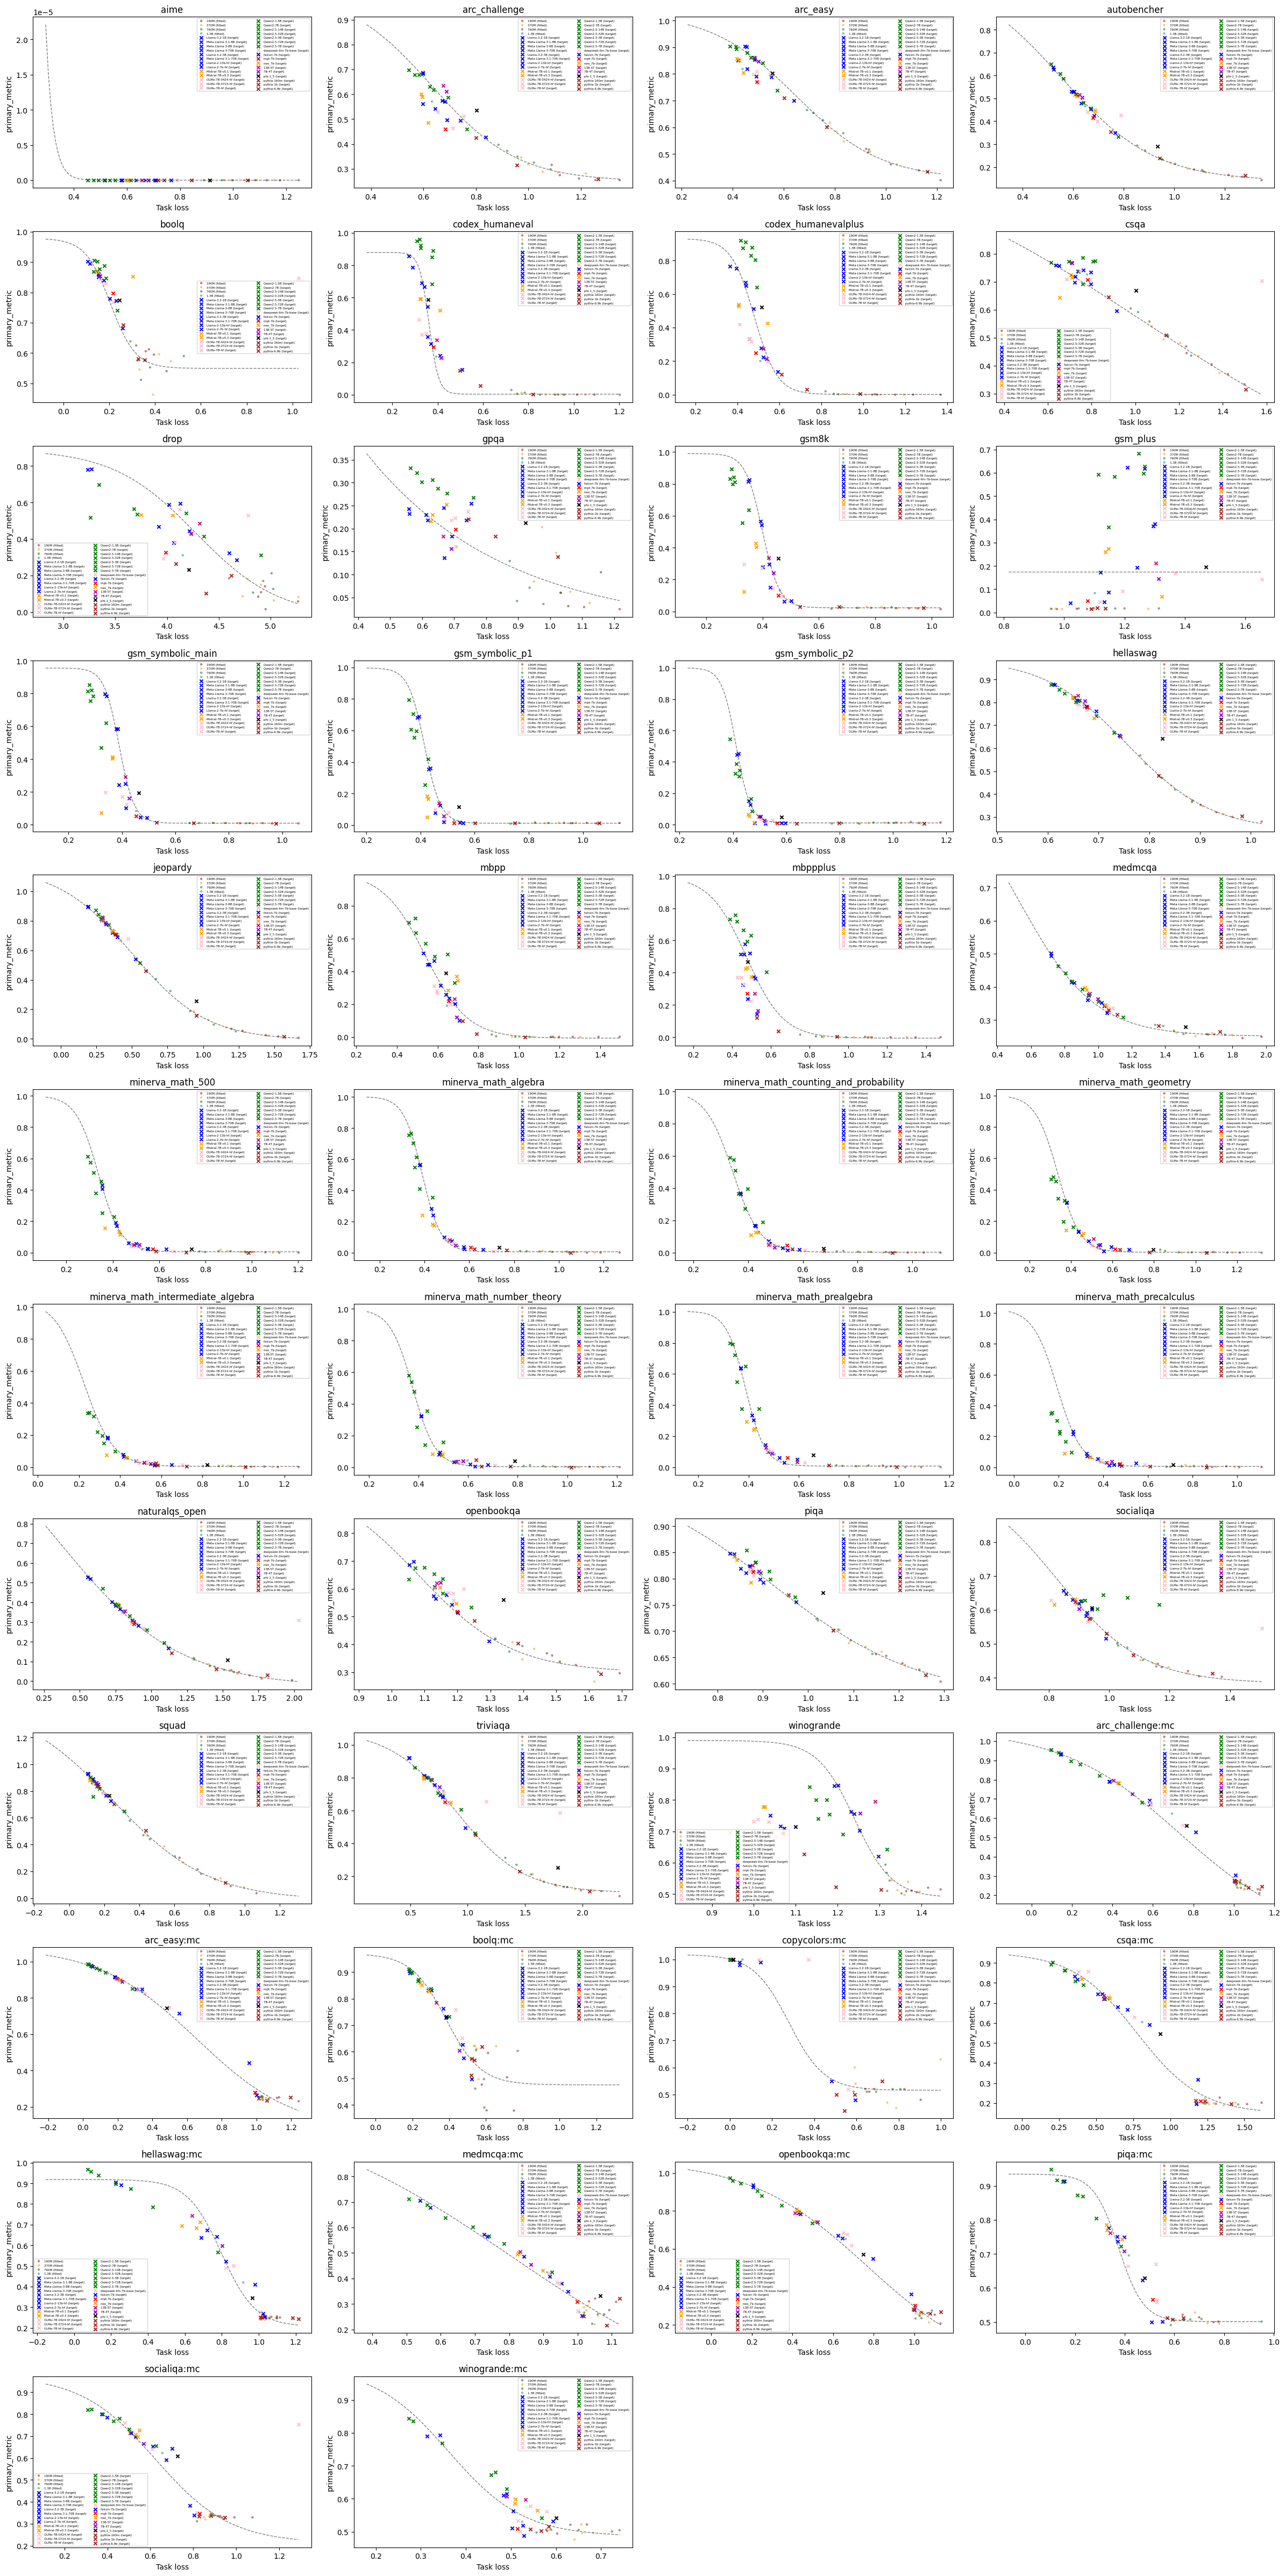

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)  # ignore fitting warnings

selected_tasks = [
    t
    for t in TASKS
    if ":" not in t
    and "bbh" not in t
    and "agi_eval_" not in t
    and "mmlu" not in t
    and "paloma" not in t
    and "coqa" not in t
    and "deepmind" not in t
]

selected_tasks += [
    t
    for t in TASKS
    if ":mc" in t
    and "bbh" not in t
    and "agi_eval_" not in t
    and "mmlu" not in t
    and "paloma" not in t
    and "codex" not in t
    and "coqa" not in t
    and "deepmind" not in t
]

cols = 4
rows = int(np.ceil(len(selected_tasks) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), squeeze=False)

for i, task in tqdm(enumerate(selected_tasks), total=len(selected_tasks)):
    row, col = divmod(i, cols)
    ax = axes[row, col]
    try:
        _, _, _ = run_ladder(
            df,
            task,
            # train_models=all_ladder_models + LLAMA_3_MODELS,
            train_models=[l for l in all_ladder_models if '3B' not in l] + LLAMA_3_MODELS,
            # eval_models=["peteish7", "peteish13-highlr"],
            eval_models=all_models,
            # intermediate_feature="paloma_m2d2_s2orc_unsplit",
            # intermediate_feature="arc_challenge",
            # eval_models=all_models,
            config_path=ladder_config_path,
            # run_step1=False, run_step2=False,
            run_step1=False, run_stacked=False,
            axes=[ax],
        )
        ax.legend(fontsize=4, ncols=2)
        ax.set_ylabel('primary_metric')
    except Exception as e:
        print(task, e)
        pass

for i in range(len(selected_tasks), rows * cols):
    row, col = divmod(i, cols)
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

RuntimeError: 

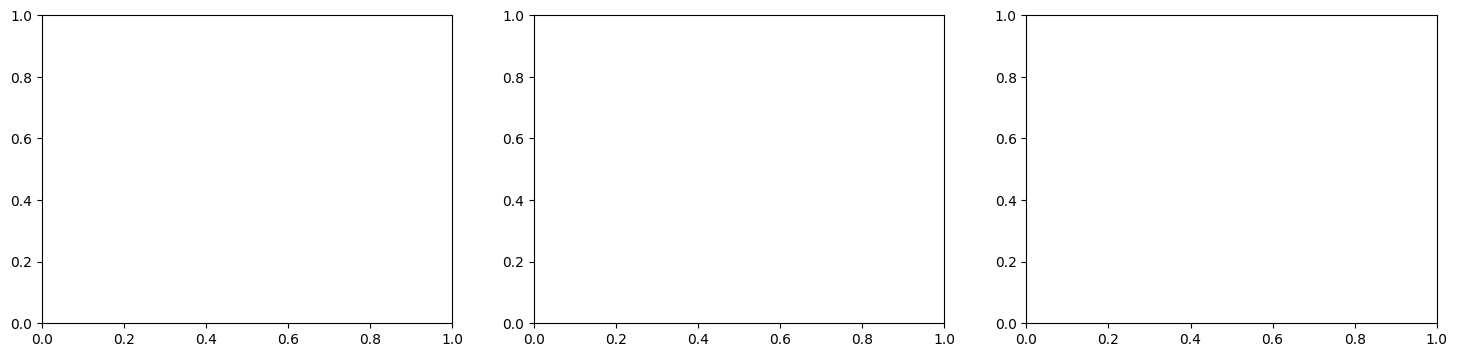

In [11]:
import matplotlib.pyplot as plt
from ladder import run_ladder

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

raise RuntimeError()

for task in TASKS:
    if 'bbh' in task:
        # BBH does not have a gold CoT, so no bpb
        continue

    if 'agi_eval' in task and ':cot' in task:
        # AGI Eval CoT does not have a gold CoT, so no bpb
        continue

    print(task)
    
    try:
        _, _, _ = run_ladder(
            df,
            task,
            train_models=all_ladder_models,
            eval_models=["peteish7", "peteish13-highlr"],
            # intermediate_feature="paloma_m2d2_s2orc_unsplit",
            # eval_models=all_models,
            config_path=ladder_config_path,
            axes=axes[0],
        )

        for ax in axes[0]:
            ax.legend(fontsize=4, ncols=2)
    except Exception as e:
        print(e)
        continue

    plt.show()
    plt.close()